# LLM Robustness under Context Perturbation — Results

**Read this notebook first.** It is the guided tour of the project: the task, the
six context conditions, the headline results (always next to trivial baselines),
the confidence-measurement bug I found and fixed, and the significance tests.

Everything below runs **CPU-only** and imports the project package
(`llm_robustness`) rather than redefining logic — it reads the committed
prediction dumps in `results/raw_predictions/`. The seven exploratory notebooks
next to this one are kept as a record of how the work was done.

See also: [`README.md`](../README.md) · [`docs/findings.md`](../docs/findings.md)
· [`docs/methodology.md`](../docs/methodology.md)

In [1]:
# Run from the repo root whether launched here or from notebooks/.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import json
import pandas as pd
from IPython.display import Image, display

import llm_robustness
from llm_robustness import report, metrics, labels
print("llm_robustness", llm_robustness.__version__, "| labels:", labels.LABELS)

llm_robustness 0.2.0 | labels: ['support', 'deny', 'query', 'comment']


## 1. Task and data splits

RumourEval-2019 stance classification (support / deny / query / comment). The
dev split is the held-out **test** set; a **thread-level** validation slice is
carved from train (thread-level so the context conditions can't leak sibling-reply
text across folds). Manifest produced by `make splits`.

In [2]:
manifest = json.load(open("results/split_manifest.json"))
pd.DataFrame({fold: manifest[fold] for fold in ["fit", "val", "test"]}).T[["n", "n_threads", "labels"]]

,n,n_threads,labels
fit,4468,293,"{'comment': 3236, 'deny': 315, 'support': 568,..."
val,422,33,"{'comment': 272, 'query': 24, 'deny': 52, 'sup..."
test,1447,38,"{'comment': 1181, 'deny': 79, 'support': 73, '..."


The six **context conditions** (target reply held fixed; only surrounding context changes):

| condition | context |
|---|---|
| `reply_only` | target reply only |
| `useful` | source rumour + parent reply |
| `irrelevant` | source + a stance-free comment (lowest lexical overlap) |
| `conflicting` | source + a real opposing-stance reply |
| `mixed` | source + parent + a conflicting reply |
| `lexical` | a distractor asserting the **opposite** of the true stance (label-aware) |

## 2. Results vs. trivial baselines

On dev/test, `comment` alone is ~82%, so the majority-class baseline is ~0.816.
Every accuracy number must be read against it.

In [3]:
all_cls, all_conf = report.run_analysis()   # recompute from committed dumps
CONDITIONS = report.CONDITIONS

rows = []
for model, conds in all_cls.items():
    for cond, m in conds.items():
        rows.append({"model": model, "condition": cond,
                     "acc": round(m["accuracy"], 3),
                     "macroF1": round(m["macro_f1"], 3),
                     "majAcc": round(m["baseline_majority_acc"], 3),
                     "commentF1": round(m["per_class_f1"][3], 3),
                     "#cls": m["n_distinct_predicted_classes"]})
df = pd.DataFrame(rows)
df[df.condition == "reply_only"].set_index("model").drop(columns="condition")

,acc,macroF1,majAcc,commentF1,#cls
model,,,,,
qwen0.5B-zeroshot,0.096,0.080,0.816,0.000,2
qwen1.5B-adv-FT,0.823,0.331,0.815,0.901,3
qwen3B-zeroshot,0.628,0.345,0.816,0.775,4
qwen3B-adv-FT,0.825,0.291,0.816,0.903,3


In [4]:
# Accuracy across all six conditions (rows) per model (cols)
df.pivot(index="condition", columns="model", values="acc").reindex(CONDITIONS)

model,qwen0.5B-zeroshot,qwen1.5B-adv-FT,qwen3B-adv-FT,qwen3B-zeroshot
condition,,,,
reply_only,0.096,0.823,0.825,0.628
useful,0.090,0.848,0.850,0.635
irrelevant,0.079,0.846,0.845,0.697
conflicting,0.088,0.854,0.858,0.700
mixed,0.087,0.850,0.852,0.644
lexical,0.093,0.841,0.851,0.598


**Read-out.** The 0.5B zero-shot model collapses (2 classes, `comment` F1 = 0.00).
The 3B zero-shot model is reasonable but weakest under the adversarial `lexical`
distractor. Both adversarially fine-tuned models beat the majority baseline and
stay flat across conditions.

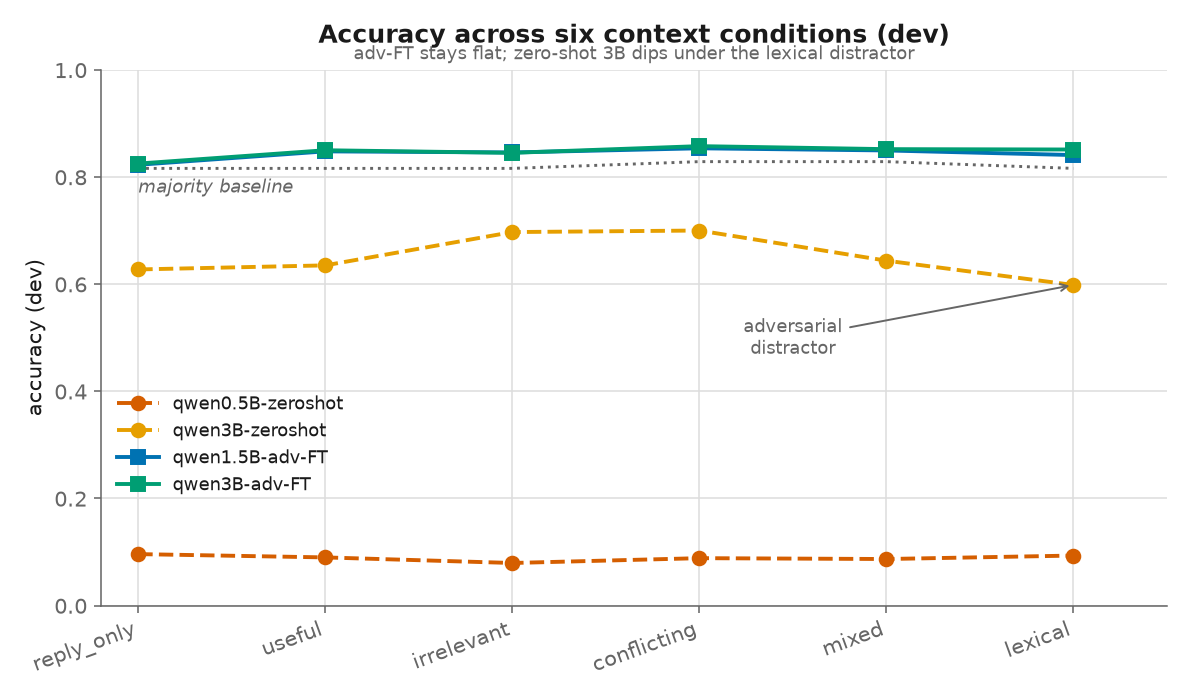

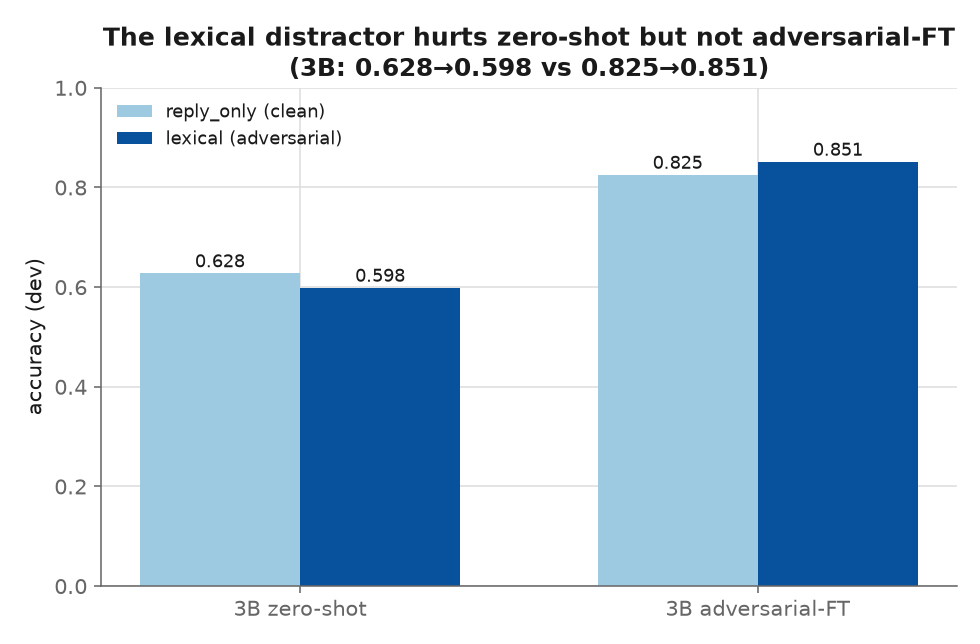

In [5]:
display(Image(filename="figures/robustness_by_condition.png"))
display(Image(filename="figures/adversarial_lexical_effect.png"))

## 3. Per-class F1 — the honest limitation

Beating majority *accuracy* is not the same as being a good classifier: macro-F1
stays modest because the minority stances are hard. The models predict 3 of 4
classes.

,support,deny,query,comment
model,,,,
qwen0.5B-zeroshot,0.000,0.128,0.192,0.000
qwen1.5B-adv-FT,0.000,0.000,0.423,0.901
qwen3B-zeroshot,0.026,0.163,0.416,0.775
qwen3B-adv-FT,0.000,0.000,0.263,0.903


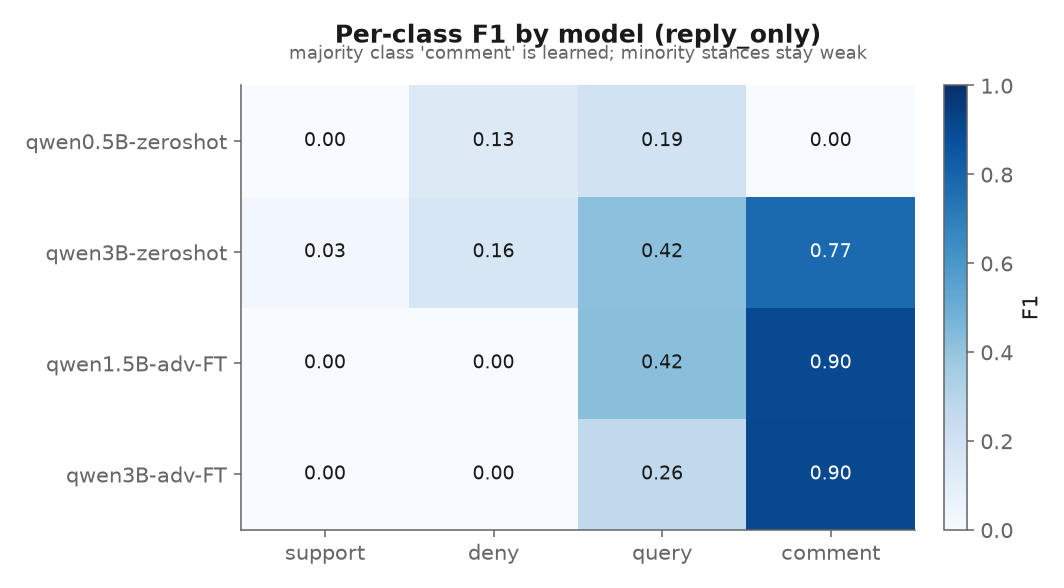

In [6]:
pc = [{"model": m, **{lab: round(c["reply_only"]["per_class_f1"][i], 3)
                      for i, lab in enumerate(labels.LABELS)}}
      for m, c in all_cls.items()]
display(pd.DataFrame(pc).set_index("model"))
display(Image(filename="figures/per_class_f1_heatmap.png"))

## 4. The confidence-measurement bug I found and fixed

The original "models are more confident when wrong" result came from a confidence
pipeline with three bugs: (1) no chat template at scoring time, (2) it scored the
*no-leading-space* label tokens (`deny`=89963) instead of the tokens the model
emits in context (`" deny"`=23101), and (3) a train/dev-contaminated split. The
same 1.5B model scores **0.82** under the correct generation pipeline but **0.10**
under the flawed confidence pipeline — so the calibration story was an artifact.

In [7]:
gen = all_cls["qwen1.5B-adv-FT"]["reply_only"]
conf = all_conf["qwen_1.5b_adv_ORIGINAL_FLAWED"]["reply_only"]
pd.DataFrame([
    {"pipeline": "generation (chat template, correct)", "accuracy": round(gen["accuracy"], 3),
     "ECE": None, "conf|right": None, "conf|wrong": None},
    {"pipeline": "confidence (ORIGINAL, flawed)", "accuracy": round(conf["accuracy"], 3),
     "ECE": round(conf["ece"], 3), "conf|right": round(conf["mean_conf_when_right"], 3),
     "conf|wrong": round(conf["mean_conf_when_wrong"], 3)},
])

,pipeline,accuracy,ECE,conf|right,conf|wrong
0,"generation (chat template, correct)",0.823,NaN,NaN,NaN
1,"confidence (ORIGINAL, flawed)",0.099,0.704,0.789,0.804


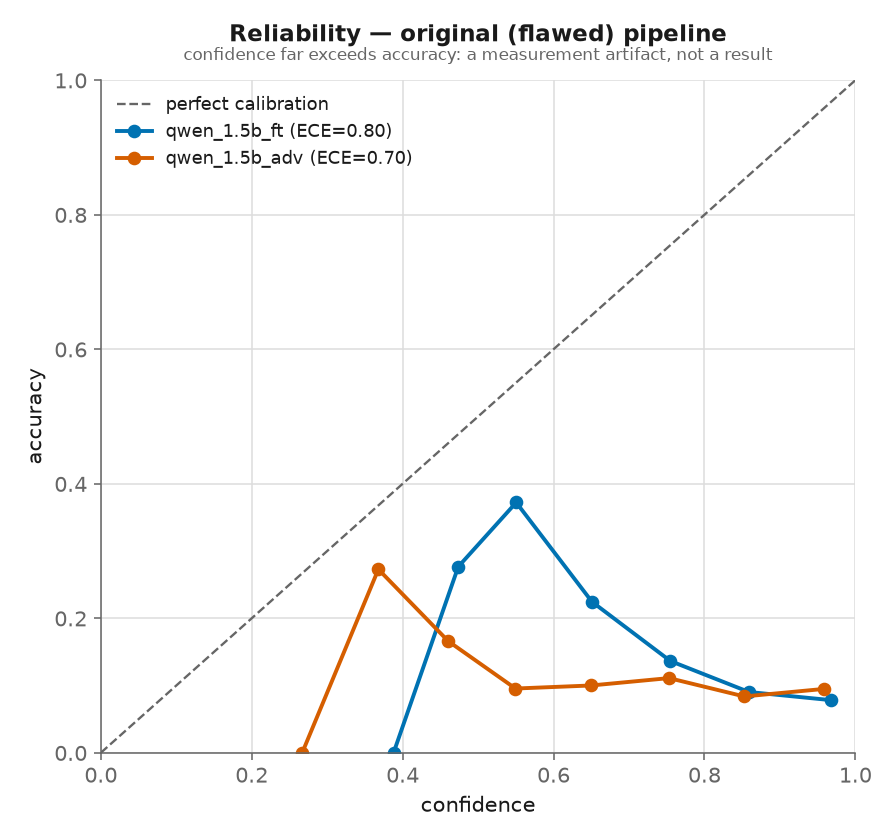

In [8]:
display(Image(filename="figures/reliability_original_flawed.png"))

The fix lives in `llm_robustness/calibrate.py` (chat template + correct
leading-space token ids + clean split); the flawed dumps are kept only to
quantify the artifact. Full write-up: [`docs/findings.md`](../docs/findings.md).

## 5. Significance (paired McNemar across conditions)

`metrics.mcnemar_test` (exact binomial for small discordant totals, chi-square
with continuity correction otherwise), paired per `reply_id`.

In [9]:
sig = report.compute_significance()
srows = [{"model": m, "comparison": comp, "b": r["b"], "c": r["c"],
          "p_value": f"{r['p_value']:.2e}", "method": r["method"]}
         for m, mr in sig.items() for comp, r in mr.items()]
pd.DataFrame(srows)

,model,comparison,b,c,p_value,method
0,qwen_1.5b_ft_ORIGINAL_FLAWED,reply_only_vs_useful,175,63,6.24e-13,chi2_continuity
1,qwen_1.5b_ft_ORIGINAL_FLAWED,reply_only_vs_irrelevant,177,40,2.65e-20,chi2_continuity
2,qwen_1.5b_ft_ORIGINAL_FLAWED,reply_only_vs_conflicting,165,44,1.04e-16,chi2_continuity
3,qwen_1.5b_ft_ORIGINAL_FLAWED,reply_only_vs_mixed,177,47,6.74e-18,chi2_continuity
4,qwen_1.5b_ft_ORIGINAL_FLAWED,reply_only_vs_lexical,94,77,2.21e-01,chi2_continuity
5,qwen_1.5b_adv_ORIGINAL_FLAWED,reply_only_vs_useful,297,550,4.77e-18,chi2_continuity
6,qwen_1.5b_adv_ORIGINAL_FLAWED,reply_only_vs_irrelevant,305,582,1.91e-20,chi2_continuity
7,qwen_1.5b_adv_ORIGINAL_FLAWED,reply_only_vs_conflicting,276,524,2.49e-18,chi2_continuity
8,qwen_1.5b_adv_ORIGINAL_FLAWED,reply_only_vs_mixed,318,616,2.52e-22,chi2_continuity
9,qwen_1.5b_adv_ORIGINAL_FLAWED,reply_only_vs_lexical,143,656,2.50e-73,chi2_continuity


## 6. What holds, and what does not

**Defensible:** adversarial fine-tuning restores robustness to the lexical
distractor (3B: 0.628 → 0.851); zero-shot small models are imbalance-sensitive
and the 0.5B model fails outright.

**Not yet established:** any calibration claim — the corrected `calibrate.py`
must be re-run on GPU first. The original miscalibration finding was a
measurement artifact.

**Limitations:** modest minority-class F1 (~0.30–0.40 macro), a label-aware
(oracle) lexical condition, and dev-as-test (the official RumourEval test set can
be dropped in via `--split test`).